In [1]:
# import libraries
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt 


In [2]:
# lets import the dataset (here we are gonna use processed_datatcsv)
df = pd.read_csv("processed_data.csv")

In [3]:
df


,Unnamed: 0,clean_text,status,statement_length,num_words,vocabulary_size,avg_word_length
0,0,oh gosh,3,1.945910,0.693147,0.693147,1.386294
1,1,trouble sleeping confused mind restless heart ...,3,3.912023,1.945910,1.945910,1.945910
2,2,wrong back dear forward doubt stay restless re...,3,4.060443,2.197225,2.079442,1.791759
3,3,shifted focus something else still worried,3,3.737670,1.791759,1.791759,1.945910
4,4,restless restless month boy mean,3,3.465736,1.609438,1.386294,1.791759
...,...,...,...,...,...,...,...
52540,53040,nobody takes seriously i’ve dealt depressionan...,3,7.056175,5.164786,4.969813,1.945910
52541,53041,selfishness not feel good like not belong worl...,3,6.368187,4.532599,4.317488,1.791759
52542,53042,way sleep better ca not sleep nights meds not ...,3,3.912023,2.302585,2.079442,1.609438
52543,53043,public speaking tips hi give presentation work...,3,5.564520,3.663562,3.496508,1.945910


In [4]:
# lets drop the columns
df.drop(columns = "Unnamed: 0",inplace = True)

In [5]:
df.sample(5)


,clean_text,status,statement_length,num_words,vocabulary_size,avg_word_length
4690,raya clothes not get b raya really wear dormit...,0,4.290459,2.564949,2.397895,1.791759
28145,perhaps result feel awful wanting feel like in...,5,5.789960,3.912023,3.610918,1.945910
1877,hello help tag account sick account,0,3.555348,1.791759,1.609438,1.791759
11255,lost interest everything nothing seems fun int...,1,6.304449,4.394449,3.970292,1.945910
47764,feel really lonely isolated reason friends not...,1,5.693732,3.850148,3.737670,1.791759


In [6]:
# here we train different Ml models and  
# we work with different models


In [7]:
# here we do not use the the straify  = labels 


# lets now do word to number transfromation
from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest = train_test_split(df.drop("status", axis=1),df["status"],test_size = 0.2,random_state=1,stratify=df["status"])

In [8]:
xtrain.shape

(42036, 5)

In [9]:
xtest.shape

(10509, 5)

In [10]:
ytrain.shape

(42036,)

In [11]:
ytest.shape

(10509,)

In [12]:
# now lets make a pipeline for testing the logistic regression model using tf-idf vectorizer


In [13]:
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer

num_cols = ["statement_length", "num_words", "vocabulary_size", "avg_word_length"]

preprocessor = ColumnTransformer([
    ("text", TfidfVectorizer(), "clean_text"),   # preprocessed text
    ("num", "passthrough", num_cols)             # numeric features
])

In [14]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

In [15]:
param_grid = {
    # TF-IDF tuning
    "preprocess__text__max_features": [5000, 10000, 15000],
    "preprocess__text__ngram_range": [(1,1), (1,2)],
}

In [16]:
from sklearn.model_selection import GridSearchCV

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=3,
    scoring="f1_weighted",
    n_jobs=-1,
    verbose=3
)

grid.fit(xtrain, ytrain)

Fitting 3 folds for each of 6 candidates, totalling 18 fits


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('preprocess',
                                        ColumnTransformer(transformers=[('text',
                                                                         TfidfVectorizer(),
                                                                         'clean_text'),
                                                                        ('num',
                                                                         'passthrough',
                                                                         ['statement_length',
                                                                          'num_words',
                                                                          'vocabulary_size',
                                                                          'avg_word_length'])])),
                                       ('model',
                                        LogisticRegression(max_iter=1000))]),
             n_jobs=-1,
             param_grid={'preprocess__text__max_features': [5000, 10000, 15000],
                         'preprocess__text__ngram_range': [(1, 1), (1, 2)]},
             scoring='f1_weighted', verbose=3)

In [17]:
print("Best Params:", grid.best_params_)
print("Best Score:", grid.best_score_)

Best Params: {'preprocess__text__max_features': 10000, 'preprocess__text__ngram_range': (1, 1)}
Best Score: 0.7490633326174487


In [18]:
from sklearn.metrics import classification_report

y_pred = grid.predict(xtest)

print(classification_report(ytest, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.95      0.91      3243
           1       0.68      0.74      0.71      3081
           2       0.67      0.64      0.65      2129
           3       0.81      0.74      0.77       768
           4       0.88      0.72      0.79       555
           5       0.69      0.45      0.55       518
           6       0.84      0.47      0.60       215

    accuracy                           0.76     10509
   macro avg       0.78      0.67      0.71     10509
weighted avg       0.76      0.76      0.76     10509



In [22]:
# lets now make pipeline for rest of the models

num_cols = ["statement_length", "num_words", "vocabulary_size", "avg_word_length"]

preprocessor = ColumnTransformer([
    ("text", TfidfVectorizer(max_features=10000), "clean_text"),
    ("num", "passthrough", num_cols)
])


In [23]:
# now lets call our everymodels for checking there base performance
from sklearn.naive_bayes import MultinomialNB, BernoulliNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression


# Ensemble models
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, BaggingClassifier

# Advanced boosting
from sklearn.neighbors import KNeighborsClassifier

# External libraries
# from xgboost import XGBClassifier
# from lightgbm import LGBMClassifier
# from catboost import CatBoostClassifier


In [24]:
models = {
    "MultinomialNB": MultinomialNB(),
    "BernoulliNB": BernoulliNB(),
    "LogisticRegression": LogisticRegression(max_iter=1000),
    "DecisionTree": DecisionTreeClassifier(),
     

    "KNN": KNeighborsClassifier(),

    "RandomForest": RandomForestClassifier(),
    "Bagging": BaggingClassifier(),
    "AdaBoost": AdaBoostClassifier(),
    "GradientBoosting": GradientBoostingClassifier(),

    # "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='mlogloss'),
    # "LightGBM": LGBMClassifier(),
    # "CatBoost": CatBoostClassifier(verbose=0)
}

In [25]:
from sklearn.metrics import (confusion_matrix, classification_report,roc_curve, auc,accuracy_score)


===== MultinomialNB =====


d:\1Rohit\Mentalhealth\ml_env\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
d:\1Rohit\Mentalhealth\ml_env\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
d:\1Rohit\Mentalhealth\ml_env\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
d:\1Rohit\Mentalhealth\ml

              precision    recall  f1-score   support

           0       0.86      0.87      0.86      3243
           1       0.50      0.85      0.63      3081
           2       0.71      0.45      0.55      2129
           3       0.86      0.48      0.62       768
           4       0.95      0.25      0.39       555
           5       0.88      0.04      0.08       518
           6       0.00      0.00      0.00       215

    accuracy                           0.66     10509
   macro avg       0.68      0.42      0.45     10509
weighted avg       0.71      0.66      0.63     10509



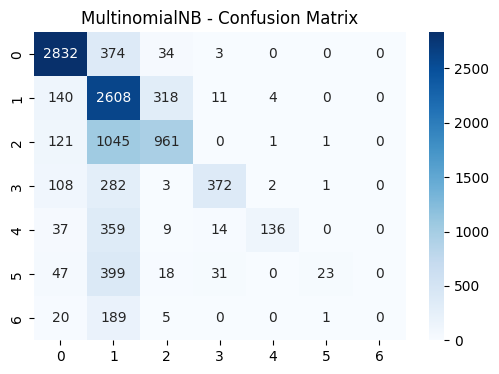


===== BernoulliNB =====
              precision    recall  f1-score   support

           0       0.64      0.93      0.76      3243
           1       0.69      0.39      0.50      3081
           2       0.54      0.50      0.52      2129
           3       0.70      0.53      0.60       768
           4       0.61      0.62      0.62       555
           5       0.41      0.50      0.45       518
           6       0.30      0.46      0.36       215

    accuracy                           0.61     10509
   macro avg       0.56      0.56      0.54     10509
weighted avg       0.62      0.61      0.59     10509



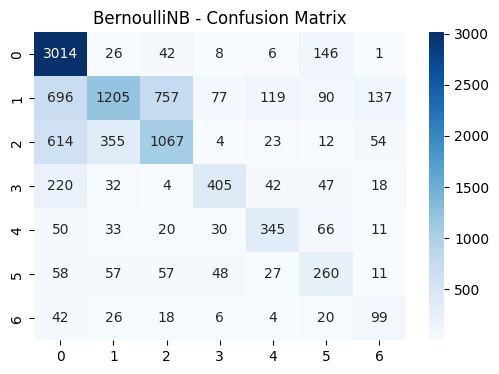


===== LogisticRegression =====
              precision    recall  f1-score   support

           0       0.87      0.95      0.91      3243
           1       0.68      0.74      0.71      3081
           2       0.67      0.64      0.65      2129
           3       0.81      0.74      0.77       768
           4       0.88      0.72      0.79       555
           5       0.69      0.45      0.55       518
           6       0.84      0.47      0.60       215

    accuracy                           0.76     10509
   macro avg       0.78      0.67      0.71     10509
weighted avg       0.76      0.76      0.76     10509



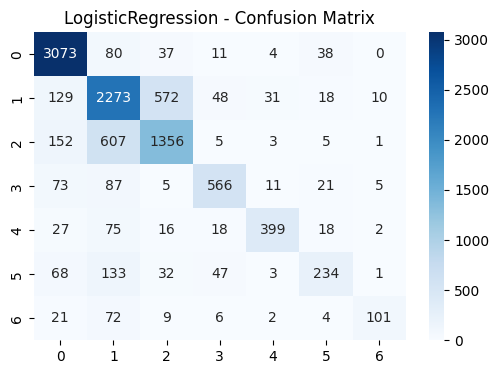


===== DecisionTree =====
              precision    recall  f1-score   support

           0       0.84      0.87      0.85      3243
           1       0.61      0.62      0.61      3081
           2       0.53      0.52      0.52      2129
           3       0.64      0.60      0.62       768
           4       0.59      0.57      0.58       555
           5       0.46      0.43      0.44       518
           6       0.61      0.60      0.61       215

    accuracy                           0.66     10509
   macro avg       0.61      0.60      0.61     10509
weighted avg       0.66      0.66      0.66     10509



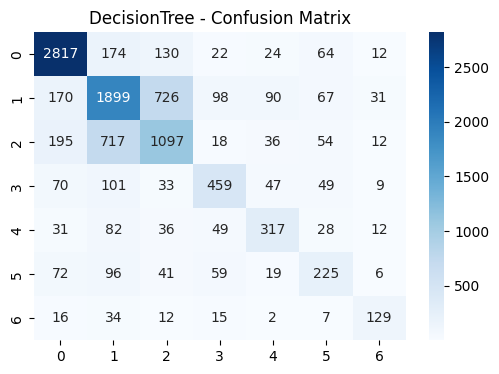


===== KNN =====
              precision    recall  f1-score   support

           0       0.67      0.93      0.78      3243
           1       0.54      0.57      0.55      3081
           2       0.50      0.39      0.44      2129
           3       0.75      0.46      0.57       768
           4       0.69      0.40      0.51       555
           5       0.59      0.21      0.31       518
           6       0.67      0.22      0.33       215

    accuracy                           0.61     10509
   macro avg       0.63      0.46      0.50     10509
weighted avg       0.60      0.61      0.58     10509



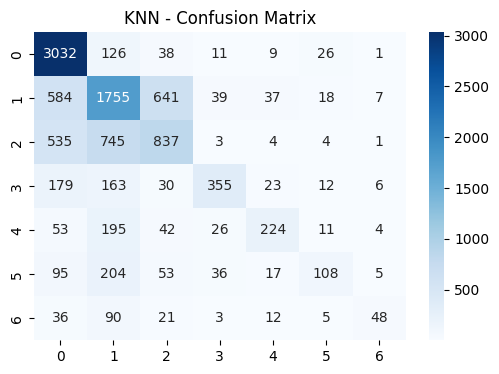


===== RandomForest =====
              precision    recall  f1-score   support

           0       0.85      0.92      0.88      3243
           1       0.55      0.82      0.66      3081
           2       0.67      0.45      0.54      2129
           3       0.89      0.54      0.68       768
           4       0.96      0.49      0.65       555
           5       0.93      0.24      0.38       518
           6       1.00      0.39      0.56       215

    accuracy                           0.70     10509
   macro avg       0.84      0.55      0.62     10509
weighted avg       0.74      0.70      0.69     10509



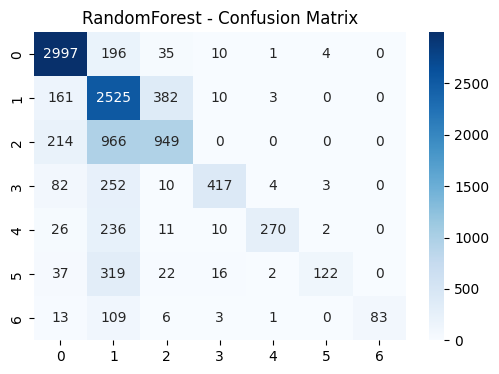


===== Bagging =====
              precision    recall  f1-score   support

           0       0.83      0.92      0.87      3243
           1       0.63      0.72      0.67      3081
           2       0.61      0.53      0.57      2129
           3       0.72      0.68      0.70       768
           4       0.79      0.61      0.69       555
           5       0.64      0.39      0.49       518
           6       0.88      0.57      0.69       215

    accuracy                           0.71     10509
   macro avg       0.73      0.63      0.67     10509
weighted avg       0.71      0.71      0.71     10509



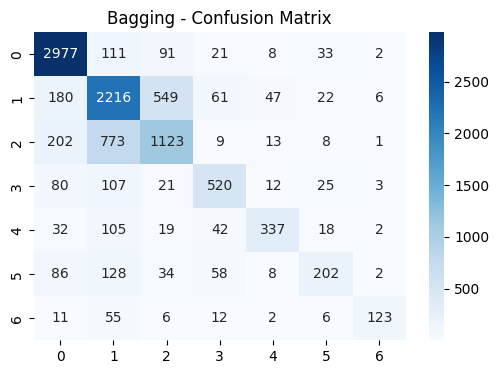


===== AdaBoost =====


d:\1Rohit\Mentalhealth\ml_env\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


              precision    recall  f1-score   support

           0       0.74      0.93      0.82      3243
           1       0.63      0.63      0.63      3081
           2       0.62      0.53      0.57      2129
           3       0.70      0.59      0.64       768
           4       0.79      0.60      0.68       555
           5       0.60      0.36      0.45       518
           6       0.83      0.50      0.63       215

    accuracy                           0.68     10509
   macro avg       0.70      0.59      0.63     10509
weighted avg       0.68      0.68      0.67     10509



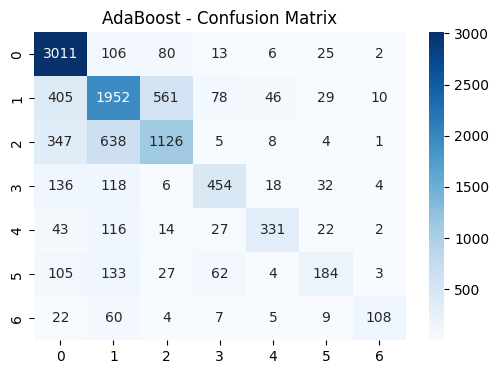


===== GradientBoosting =====
              precision    recall  f1-score   support

           0       0.84      0.91      0.87      3243
           1       0.62      0.74      0.68      3081
           2       0.68      0.58      0.62      2129
           3       0.78      0.63      0.70       768
           4       0.88      0.69      0.78       555
           5       0.68      0.39      0.50       518
           6       0.80      0.56      0.66       215

    accuracy                           0.73     10509
   macro avg       0.76      0.64      0.69     10509
weighted avg       0.73      0.73      0.72     10509



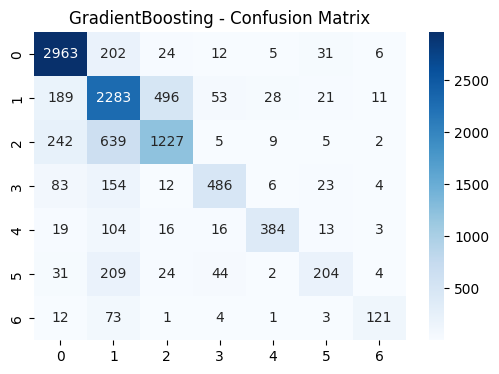

In [26]:
from sklearn.pipeline import Pipeline

results = []

for name, model in models.items():
    print(f"\n===== {name} =====")
    
    pipeline = Pipeline([
        ("preprocess", preprocessor),
        ("model", model)
    ])
    
    # Train
    pipeline.fit(xtrain, ytrain)
    
    # Predict
    y_pred = pipeline.predict(xtest)
    
    # Metrics
    acc = accuracy_score(ytest, y_pred)
    report = classification_report(ytest, y_pred, output_dict=True)
    
    precision = report["weighted avg"]["precision"]
    recall = report["weighted avg"]["recall"]
    f1 = report["weighted avg"]["f1-score"]
    
    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1
    })
    
    print(classification_report(ytest, y_pred))
    
    cm = confusion_matrix(ytest, y_pred)
    
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")
    plt.title(f"{name} - Confusion Matrix")
    plt.show()

In [27]:
results

[{'Model': 'MultinomialNB',
  'Accuracy': 0.6596250832619659,
  'Precision': 0.7112343060092303,
  'Recall': 0.6596250832619659,
  'F1-score': 0.6324378080841302},
 {'Model': 'BernoulliNB',
  'Accuracy': 0.6085260253116377,
  'Precision': 0.6213983814834781,
  'Recall': 0.6085260253116377,
  'F1-score': 0.5927297685730661},
 {'Model': 'LogisticRegression',
  'Accuracy': 0.7614425730326387,
  'Precision': 0.7603460526439835,
  'Recall': 0.7614425730326387,
  'F1-score': 0.7570848534605896},
 {'Model': 'DecisionTree',
  'Accuracy': 0.6606718051194215,
  'Precision': 0.6572411953919767,
  'Recall': 0.6606718051194215,
  'F1-score': 0.6587675478880445},
 {'Model': 'KNN',
  'Accuracy': 0.6051003901417832,
  'Precision': 0.5999744475677858,
  'Recall': 0.6051003901417832,
  'F1-score': 0.5832002804196377},
 {'Model': 'RandomForest',
  'Accuracy': 0.7006375487677229,
  'Precision': 0.7411955127725789,
  'Recall': 0.7006375487677229,
  'F1-score': 0.6877077521745508},
 {'Model': 'Bagging',
  '

## 📊 Model Performance Report (TF-IDF with 10,000 Features)

---

### 🔹 Overall Performance
- **Logistic Regression** achieves the best performance:
  - Accuracy ≈ **0.76**
  - F1-score ≈ **0.76**

- **Gradient Boosting** and **Bagging** are strong alternatives:
  - Gradient Boosting F1 ≈ **0.72**
  - Bagging F1 ≈ **0.71**

- **Random Forest** performs moderately:
  - F1-score ≈ **0.69**

- **Naive Bayes Models**:
  - MultinomialNB F1 ≈ **0.63**
  - BernoulliNB F1 ≈ **0.59**

- **KNN** performs the worst:
  - F1-score ≈ **0.58**

---

## 🧠 Feature Engineering Insight
- Using **TF-IDF with 10,000 features** improves performance compared to simpler representations.
- Indicates:
  - TF-IDF effectively captures **important word significance**
  - High-dimensional sparse features are beneficial for linear models

---

## 🌲 Model Behavior Insights

### ✅ Linear Models
- **Logistic Regression** performs best
- Reason:
  - Works well with **high-dimensional sparse TF-IDF features**
  - Captures linear separability in text data effectively

---

### 🌳 Tree-Based Models
- **Random Forest, Gradient Boosting, Bagging**
  - Perform decently but below Logistic Regression

- Reason:
  - Tree models struggle with:
    - Sparse high-dimensional feature space
    - Lack of strong hierarchical feature splits in TF-IDF

---

### ⚠️ Naive Bayes Models
- **MultinomialNB performs better than BernoulliNB**
- Reason:
  - MultinomialNB is better suited for:
    - Frequency-based features (TF-IDF)
  - BernoulliNB is limited to binary presence/absence

---

### ⚠️ Distance-Based Models
- **KNN performs poorly**

- Reason:
  - High-dimensional sparse space causes:
    - Distance metrics to become ineffective
    - Curse of dimensionality

---

## 📉 Precision vs Recall Behavior
- Weighted precision and recall are **closely aligned across models**
- Indicates:
  - Balanced performance across predictions

- However:
  - Minor variations suggest:
    - Some class imbalance still exists
    - Certain classes may be harder to predict

---

## ⚖️ Observations on Model Performance

| Model                | Accuracy | F1-score |
|---------------------|---------|----------|
| LogisticRegression  | 0.76    | 0.76     |
| GradientBoosting    | 0.73    | 0.72     |
| Bagging             | 0.71    | 0.71     |
| RandomForest        | 0.70    | 0.69     |
| DecisionTree        | 0.66    | 0.66     |
| MultinomialNB       | 0.66    | 0.63     |
| AdaBoost            | 0.68    | 0.67     |
| BernoulliNB         | 0.61    | 0.59     |
| KNN                 | 0.61    | 0.58     |

---

## 🚀 Key Takeaways

- ✔ **TF-IDF significantly improves model performance**
- ✔ **Logistic Regression is the best baseline model**
- ✔ Ensemble methods provide competitive but not superior results
- ⚠ High-dimensional sparse data limits:
  - KNN
  - Tree-based models
- ⚠ Slight imbalance may still exist in class predictions

---

## 🔥 Suggested Improvements

- Use **bigram features (`ngram_range=(1,2)`)**
- Tune TF-IDF parameters:
  - `max_df`
  - `min_df`
- Apply **class balancing**:
  - `class_weight="balanced"`
- Try advanced models:
  - LightGBM / XGBoost
- Perform **hyperparameter tuning (RandomizedSearchCV)**

---

## 🎯 Final Conclusion

> Using TF-IDF with 10,000 features significantly enhances model performance, with Logistic Regression emerging as the most effective model. While ensemble methods show competitive results, linear models remain superior for high-dimensional sparse text data. Further improvements can be achieved through feature tuning and class imbalance handling.